# Detecção de Objetos na Órbita Terrestre

**Para rodar com sucesso todas as célula deste notebook, recomenda-se:**

1. Criar e ativar ambiente virtual
2. Rodar ***!pip install -r requirements.txt***

## Fazendo as importações necessárias para o projeto

In [26]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import joblib
import gradio as gr
import shap

## Criando um dataframe 

Dados gerados de forma fictícia contendo características de objetos espaciais como: Lixo Espacial (0), Satélite Ativo (1) e Asteróide (2).

In [27]:
objetos_espaciais_df = pd.read_csv('../data/objetos_espaciais_complexo.csv')
objetos_espaciais_df.head(20)

,rcs_m2,albedo_optico,taxa_rotacao_rpm,variacao_termica_k,desvio_trajetoria_prevista_m,indice_espectral_metal,rugosidade_superficie,densidade_estimada_kg_m3,variacao_brilho_luz_solar,tipo_objeto
0,1.236976,0.497537,0.256004,163.130501,0.797768,0.777927,0.416255,489.328655,0.372881,0
1,0.000000,0.336466,0.000000,118.821443,0.000000,0.770810,0.639240,1695.206068,0.627565,0
2,10.805121,0.481571,0.126598,186.227868,2.326854,0.979220,0.918116,1520.614288,0.749403,0
3,0.000000,0.581564,0.000000,202.623924,10.548409,0.578488,0.744758,3302.481420,0.631209,0
4,8.079794,0.909975,34.150586,212.219711,20.706663,0.221339,0.562618,1167.815683,0.978010,0
5,14.919426,0.304312,0.212469,153.884792,16.209121,0.483901,0.380963,3018.328582,0.780744,0
6,0.000000,0.842566,14.390706,188.852294,0.000000,0.950016,0.005074,108.798599,1.001629,0
7,7.245414,0.338461,9.006136,234.772514,18.556969,0.514458,0.393333,1074.750482,0.852093,0
8,1.297227,0.471524,19.968611,61.949322,26.626093,0.863229,0.373864,2357.897819,0.035019,0
9,2.592715,0.008412,11.107976,122.658856,31.311824,0.594237,0.426467,655.389292,0.415185,0


## Dados de Treino e Teste

- Separando dados de treino e teste para prever qual o tipo de objeto

- Alocando 70% dos dados para treino e 30% para teste.

In [28]:
x = objetos_espaciais_df.drop('tipo_objeto', axis=1)
y = objetos_espaciais_df['tipo_objeto']

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3, random_state=42)

print(xtrain.shape, xtest.shape, ytrain.shape, ytest.shape)

(3500, 9) (1500, 9) (3500,) (1500,)


## Treinamento do modelo com XGBoost

Utilizando modelo XGBoost para classificação

Foram definidas 502 árvores de decisão com profundidade máxima de 4 e taxa de aprendizado de 0.1

In [29]:
modelo_xgb = XGBClassifier(n_estimators=502, max_depth=4, learning_rate=0.1, random_state=42)
modelo_xgb.fit(xtrain, ytrain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=502, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

### Acurácia do Modelo

Foi alcançada uma acurácia de 96.4% do modelo utilizando XGBoost com os parâmetros definidos anteriormente.

In [30]:
ypred_train = modelo_xgb.predict(xtrain)
ypred_test = modelo_xgb.predict(xtest)

acuracia_treino = accuracy_score(ytrain, ypred_train)
acuracia_teste = accuracy_score(ytest, ypred_test)

print(f'Acurácia no conjunto de treino: {acuracia_treino:.4f}')
print(f'Acurácia no conjunto de teste: {acuracia_teste:.4f}')

Acurácia no conjunto de treino: 1.0000
Acurácia no conjunto de teste: 0.9640


## Feature Importance

Utilizando feature importance parar mostrar o quanto cada variável influencia na previsão do modelo

In [31]:
importancias = pd.DataFrame({
    'Feature': xtrain.columns,
    'Importância': modelo_xgb.feature_importances_
}).sort_values(by='Importância', ascending=False)

print(importancias)

                        Feature  Importância
5        indice_espectral_metal     0.216553
6         rugosidade_superficie     0.180820
2              taxa_rotacao_rpm     0.173813
8     variacao_brilho_luz_solar     0.154137
4  desvio_trajetoria_prevista_m     0.112827
0                        rcs_m2     0.071402
1                 albedo_optico     0.041688
3            variacao_termica_k     0.031375
7      densidade_estimada_kg_m3     0.017384


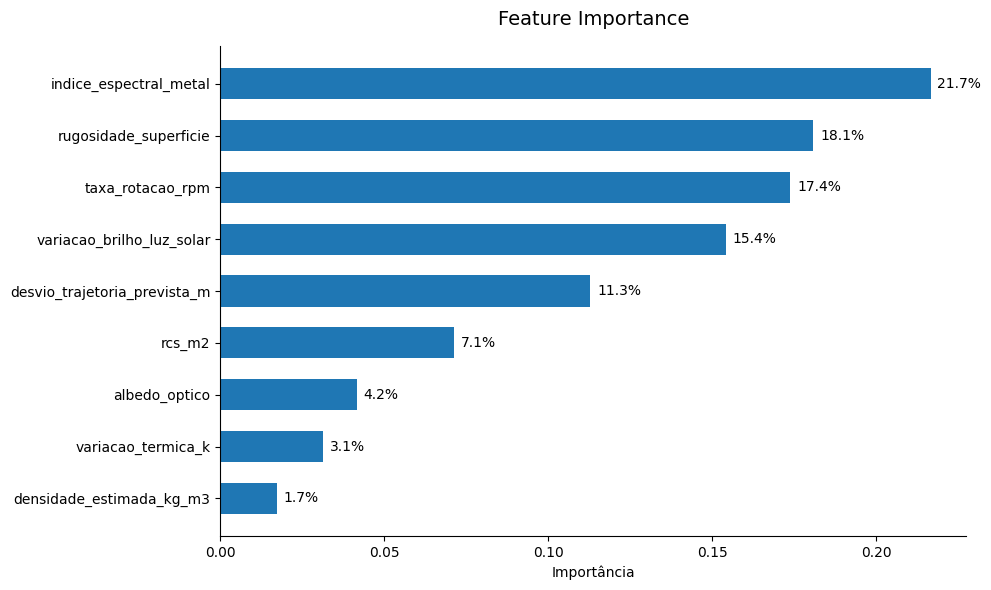

In [32]:
df_plot = importancias.sort_values(by='Importância', ascending=True).tail(9)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_plot['Feature'], df_plot['Importância'], color='#1f77b4', height=0.6)

for bar in bars:
    width = bar.get_width()
    porcentagem = width * 100 
    ax.text(
        width + 0.002,          
        bar.get_y() + bar.get_height() / 2,
        f'{porcentagem:.1f}%',       
        ha='left',
        va='center',
        fontsize=10
    )

ax.set_title('Feature Importance', fontsize=14, pad=15)
ax.set_xlabel('Importância')
ax.spines['top'].set_visible(False)  
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## SHAP

Utilizando SHAP para verificar como o modelo toma decisões

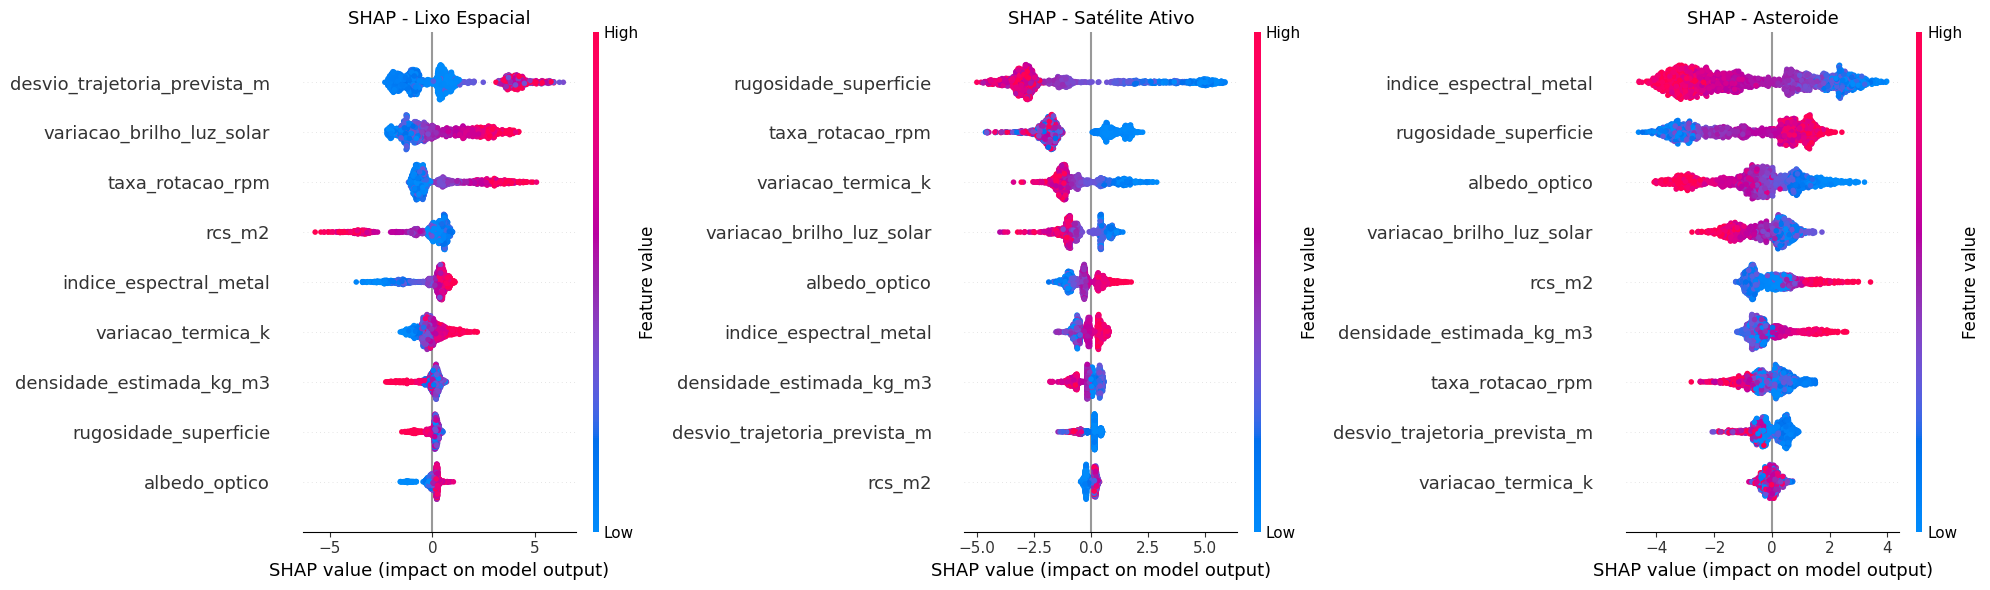

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
nomes_classes = ['Lixo Espacial', 'Satélite Ativo', 'Asteroide']

for i, nome in enumerate(nomes_classes):
    plt.sca(axes[i])
    shap.summary_plot(shap_values[:, :, i],xtest,show=False,plot_size=None)
    axes[i].set_title(f"SHAP - {nome}", fontsize=13)

plt.tight_layout()
plt.show()

Salvando modelo com joblib...

In [34]:
joblib.dump(modelo_xgb, '../models/modelo_xgb.joblib')

['../models/modelo_xgb.joblib']

Carregando o modelo...

In [35]:
modelo_xgb_carregado = joblib.load("../models/modelo_xgb.joblib")


## Deploy com Gradio

In [36]:
mapeamento = {
    0: "Lixo Espacial",
    1: "Satélite Ativo",
    2: "Asteroide"
}

def predict_price(Rcs_m2, AlbedoOptico, TaxaRotacaoRPM, VariacaoTermicaK, 
                  DesvioTrajetoriaPrevistaM, IndiceEspectralMetal, 
                  RugosidadeSuperficie, DensidadeEstimadaKgM3, VariacaoBrilhoLuzSolar):

    input_data = pd.DataFrame([{
        'rcs_m2': Rcs_m2,                                    
        'albedo_optico': AlbedoOptico,                        
        'taxa_rotacao_rpm': TaxaRotacaoRPM,                   
        'variacao_termica_k': VariacaoTermicaK,                
        'desvio_trajetoria_prevista_m': DesvioTrajetoriaPrevistaM,
        'indice_espectral_metal': IndiceEspectralMetal,
        'rugosidade_superficie': RugosidadeSuperficie,
        'densidade_estimada_kg_m3': DensidadeEstimadaKgM3,
        'variacao_brilho_luz_solar': VariacaoBrilhoLuzSolar
    }])

    prediction = modelo_xgb_carregado.predict(input_data)[0]
    return f"{mapeamento[int(prediction)]}".upper()


with gr.Blocks(title="Detecção de Objetos Espaciais - XGBoost") as app:

    gr.Markdown("""
    # Predição de Objetos Espaciais com XGBoost
    Modelo **XGBoost Classifier** treinado com o dataset **Objetos Espaciais**.
    """)

    gr.Markdown("""
    ### Legenda das Features

    | Coluna | Significado |
    |---|---|
    | `rcs_m2` | Radar Cross Section — área de reflexão do objeto no radar, em m² |
    | `albedo_optico` | Fração da luz solar refletida pelo objeto (0 = absorve tudo, 1 = reflete tudo) |
    | `taxa_rotacao_rpm` | Velocidade de rotação do objeto em torno do próprio eixo, em RPM |
    | `variacao_termica_k` | Variação de temperatura superficial do objeto, em Kelvin |
    | `desvio_trajetoria_prevista_m` | Diferença entre a trajetória real e a prevista, em metros |
    | `indice_espectral_metal` | Índice que indica a composição metálica com base na assinatura espectral |
    | `rugosidade_superficie` | Irregularidade da superfície do objeto (quanto maior, mais rugosa) |
    | `densidade_estimada_kg_m3` | Densidade estimada do objeto, em kg/m³ |
    | `variacao_brilho_luz_solar` | Variação na intensidade da luz solar refletida ao longo do tempo |
    | `tipo_objeto` | Classe: **0** = Lixo Espacial · **1** = Satélite Ativo · **2** = Asteroide |
    """)


    with gr.Row():
        with gr.Column():
            Rcs_m2 = gr.Number(label="Rcs_m2 - Área de radar (m²)", value=31.260238)
            AlbedoOptico = gr.Number(label="Albedo óptico (0-1)", value=0.199491)
            TaxaRotacaoRPM = gr.Number(label="Taxa de rotação (RPM)", value=1.690157)

        with gr.Column():
            VariacaoTermicaK = gr.Number(label="Variação térmica (K)", value=90.867466)
            DesvioTrajetoriaPrevistaM = gr.Number(label="Desvio da trajetória prevista (m)", value=4.907679)
            IndiceEspectralMetal = gr.Number(label="Índice espectral de metal", value=0.068184)

        with gr.Column():
            RugosidadeSuperficie = gr.Number(label="Rugosidade da superfície (0-1)", value=0.976906)
            DensidadeEstimadaKgM3 = gr.Number(label="Densidade estimada (kg/m³)", value=2032.525479)
            VariacaoBrilhoLuzSolar = gr.Number(label="Variação do brilho da luz solar (0-1)", value=0.213603)

    output = gr.Textbox(
        label="Objeto Detectado",
        lines=2,
        text_align="center",
    )

    with gr.Row():
        predict_button = gr.Button("Fazer predição", variant="primary")
        clear_button = gr.Button("Limpar campos", variant="secondary")

    predict_button.click(
        fn=predict_price,
        inputs=[
            Rcs_m2, AlbedoOptico, TaxaRotacaoRPM, VariacaoTermicaK, DesvioTrajetoriaPrevistaM, IndiceEspectralMetal, RugosidadeSuperficie, DensidadeEstimadaKgM3, VariacaoBrilhoLuzSolar
        ],
        outputs=output
    )

    clear_button.click(
        fn=lambda: [None, None, None, None, None, None, None, None, None, ""],
        inputs=[],
        outputs=[
            Rcs_m2, AlbedoOptico, TaxaRotacaoRPM, VariacaoTermicaK, DesvioTrajetoriaPrevistaM, IndiceEspectralMetal, RugosidadeSuperficie, DensidadeEstimadaKgM3, VariacaoBrilhoLuzSolar, output
        ]
    )

    gr.Examples(
        examples=[
            [31.260238, 0.199491, 1.690157, 90.867466, 4.907679, 0.068184, 0.976906, 2032.525479, 0.213603],
            [2.726820, 0.480800, 30.185397, 115.546072, 14.368404, 0.408652, 0.290703, 2354.226490, 0.417699],
            [6.962419, 0.831294, 0.608982, 23.282290, 3.066657, 1.003771, 0.146154, 1486.924177, 0.380237]
        ],
        inputs=[
            Rcs_m2, AlbedoOptico, TaxaRotacaoRPM, VariacaoTermicaK, DesvioTrajetoriaPrevistaM, IndiceEspectralMetal, RugosidadeSuperficie, DensidadeEstimadaKgM3, VariacaoBrilhoLuzSolar
        ]
    )

app.launch(share=True)

Running on local URL:  http://127.0.0.1:7864

Thanks for being a Gradio user! If you have questions or feedback, please join our Discord server and chat with us: https://discord.gg/feTf9x3ZSB
Running on public URL: https://59909e3b955299cc2e.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
